# XLDS Evaluation Analysis — BART on XSAMSum (Intermediate English Summaries)

This notebook analyzes per-pair evaluation scores for the **intermediate English stage** of the cross-lingual dialogue summarization (XLDS) pipeline, before the EN→ZH translation step. The evaluation file contains ROUGE-1, ROUGE-2, ROUGE-L (multilingual-rouge toolkit, English tokenizer) and BERTScore F1 (`roberta-large` per BERTScore defaults for English), reported both raw and baseline-rescaled.

**Why this stage matters.** Errors introduced here propagate into the Chinese translation, so the ceiling on final Chinese quality is set by what the English summarizer produces. Comparing these scores against the final Chinese scores tells us how much quality is lost in translation vs. lost in summarization.

**Goals of this notebook**
1. Sanity-check the distribution of each metric.
2. Identify failure modes — where the summarizer collapses (low ROUGE, low BERTScore).
3. Look at metric agreement — do ROUGE and BERTScore rank the same examples as good/bad? Does rescaling change the picture?
4. Inspect length effects — does reference length predict score?
5. Surface best / worst / most-disagreed-on examples for qualitative review.

## 1. Load and inspect

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_colwidth', 160)

CSV_PATH = 'pair_scores_en_XSAMSum_bart.csv'  # adjust if running outside the repo
df = pd.read_csv(CSV_PATH, index_col=0)
print(f'Loaded {len(df)} pairs')
df.head()

Loaded 819 pairs


,reference,prediction,rouge1,rouge2,rougeL,bs_f1_raw,bs_f1_rescaled
0,Hannah needs Betty's number but Amanda doesn't have it. She needs to contact Larry.,Hannah is looking for Betty's number. Larry called her last time they were at the park together. Hannah doesn't know him well. Amanda suggests Hannah to tex...,39.13,13.64,30.43,90.48,43.58
1,Eric and Rob are going to watch a stand-up on youtube.,Eric and Rob are watching a Russian comedian's stand-up.,69.57,47.62,69.57,94.65,68.31
2,Lenny can't decide which trousers to buy. Bob advised Lenny on that topic. Lenny goes with Bob's advice to pick the trousers that are of best quality.,Lenny will buy the first or the third pair of purple trousers from Bob.,27.91,0.00,18.60,88.91,34.28
3,Emma will be home soon and she will let Will know.,Emma doesn't want to cook dinner tonight. She will be home soon. Will will pick her up.,55.17,29.63,48.28,91.39,48.96
4,Jane is in Warsaw. Ollie and Jane has a party. Jane lost her calendar. They will get a lunch this week on Friday. Ollie accidentally called Jane and talked ...,Jane is back from Morocco. Ollie and Jane will meet for lunch on Friday at 6 pm after Jane finishes her courses.,49.23,22.22,36.92,89.77,39.38


In [2]:
ROUGE_METRICS = ['rouge1', 'rouge2', 'rougeL']
BS_METRICS = ['bs_f1_raw', 'bs_f1_rescaled']
METRICS = ROUGE_METRICS + BS_METRICS
df[METRICS].describe().round(2)

,rouge1,rouge2,rougeL,bs_f1_raw,bs_f1_rescaled
count,819.00,819.00,819.00,819.00,819.00
mean,52.94,28.33,44.43,92.71,56.83
std,17.91,20.00,18.52,2.64,15.65
min,4.88,0.00,4.88,84.41,7.65
25%,40.00,13.33,31.07,90.96,46.41
50%,51.61,26.32,42.42,92.51,55.61
75%,63.92,38.58,54.55,94.40,66.84
max,100.00,100.00,100.00,100.00,100.00


Quick sanity checks: no missing values, no duplicate references, and reference/prediction are both non-empty.

In [3]:
print('Missing values per column:')
print(df.isna().sum())
print(f"\nEmpty references:  {(df['reference'].str.len() == 0).sum()}")
print(f"Empty predictions: {(df['prediction'].str.len() == 0).sum()}")
print(f"Duplicate references: {df['reference'].duplicated().sum()}")

Missing values per column:
reference         0
prediction        0
rouge1            0
rouge2            0
rougeL            0
bs_f1_raw         0
bs_f1_rescaled    0
dtype: int64

Empty references:  0
Empty predictions: 0
Duplicate references: 0


## 2. Metric distributions

ROUGE scores are on a 0–100 scale. BERTScore F1 is reported both raw and baseline-rescaled:
- **raw** — direct cosine similarity of contextual embeddings; for English `roberta-large` this typically sits in the 85–95 range, so absolute numbers look high and compressed.
- **rescaled** — subtracts the BERTScore baseline (random pair similarity) and renormalizes, so scores spread across a wider range and are more interpretable.

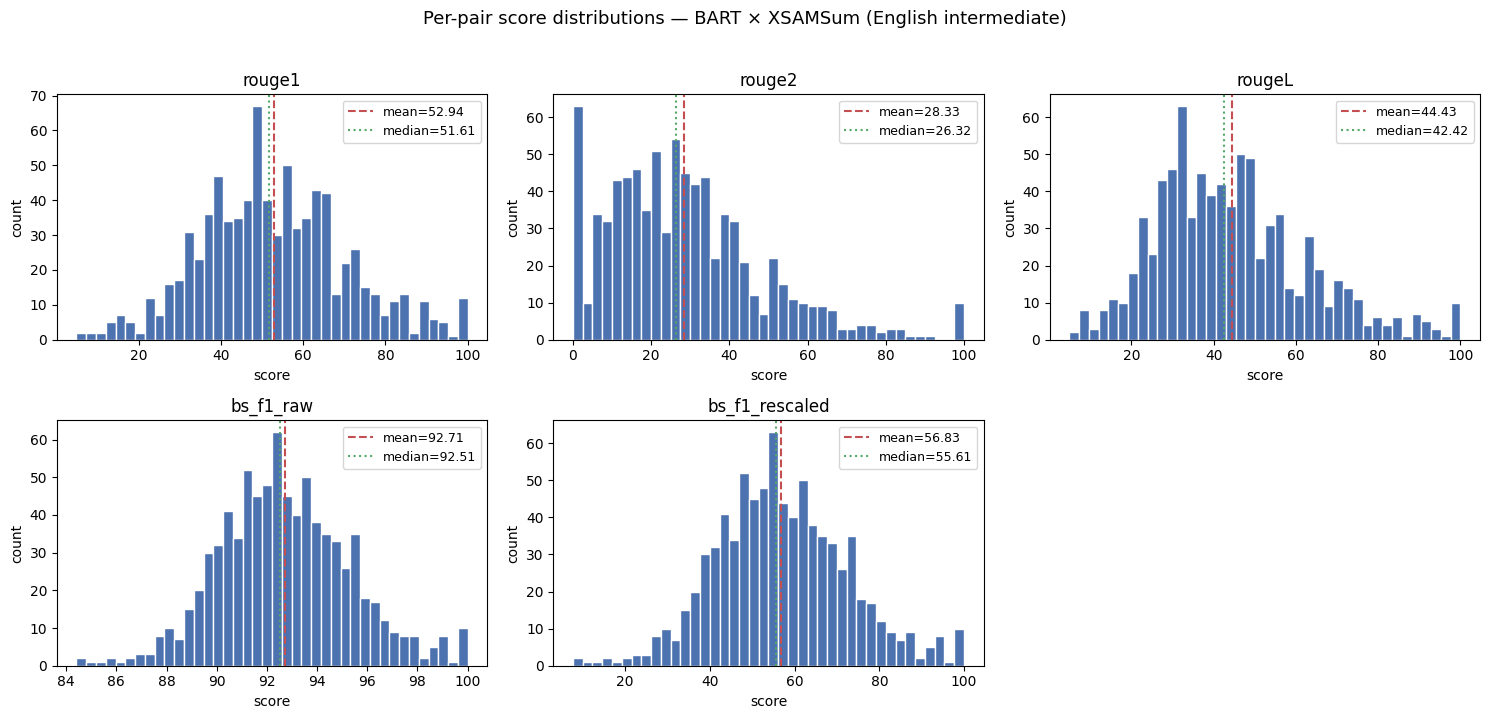

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, metric in zip(axes.ravel(), METRICS):
    ax.hist(df[metric], bins=40, color='#4C72B0', edgecolor='white')
    mean_val = df[metric].mean()
    median_val = df[metric].median()
    ax.axvline(mean_val, color='#C44E52', linestyle='--', linewidth=1.5, label=f'mean={mean_val:.2f}')
    ax.axvline(median_val, color='#55A868', linestyle=':', linewidth=1.5, label=f'median={median_val:.2f}')
    ax.set_title(metric)
    ax.set_xlabel('score')
    ax.set_ylabel('count')
    ax.legend(fontsize=9)
# Hide the unused 6th subplot
axes.ravel()[5].axis('off')
fig.suptitle('Per-pair score distributions — BART × XSAMSum (English intermediate)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

/tmp/ipykernel_14223/568374319.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([df['rouge1'], df['rouge2'], df['rougeL']], labels=['R-1', 'R-2', 'R-L'], showmeans=True)
/tmp/ipykernel_14223/568374319.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([df['bs_f1_raw'], df['bs_f1_rescaled']], labels=['BS raw', 'BS rescaled'], showmeans=True)


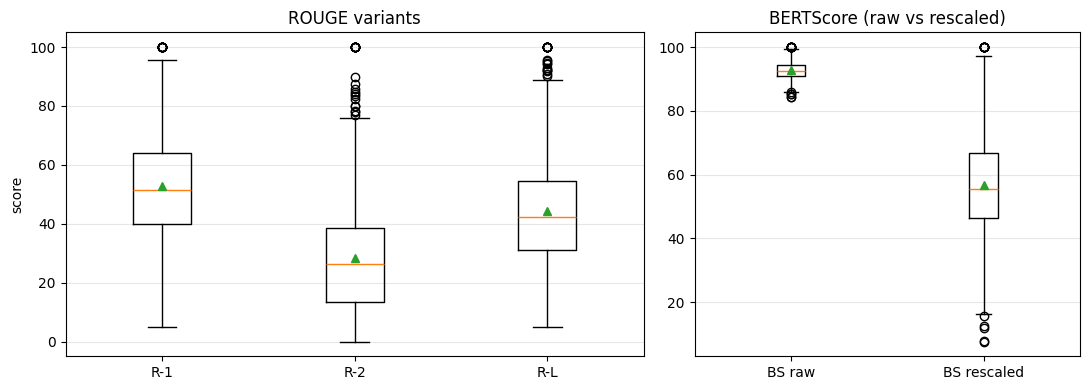

In [5]:
# Boxplot view — easier for comparing ROUGE variants and the two BERTScore flavors side by side.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={'width_ratios': [3, 2]})
ax1.boxplot([df['rouge1'], df['rouge2'], df['rougeL']], labels=['R-1', 'R-2', 'R-L'], showmeans=True)
ax1.set_title('ROUGE variants')
ax1.set_ylabel('score')
ax1.grid(axis='y', alpha=0.3)
ax2.boxplot([df['bs_f1_raw'], df['bs_f1_rescaled']], labels=['BS raw', 'BS rescaled'], showmeans=True)
ax2.set_title('BERTScore (raw vs rescaled)')
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Failure modes

Surfacing low-end cases - they tend to be the dialogues where the model hallucinated or collapsed onto a trivial summary.

In [6]:
zero_r1 = (df['rouge1'] == 0).sum()
zero_r2 = (df['rouge2'] == 0).sum()
zero_rl = (df['rougeL'] == 0).sum()
low_bs_rescaled = (df['bs_f1_rescaled'] < 30).sum()  # rescaled, so 30 is already weak

print(f"ROUGE-1 == 0:                {zero_r1:4d}  ({zero_r1/len(df):.1%})")
print(f"ROUGE-2 == 0:                {zero_r2:4d}  ({zero_r2/len(df):.1%})")
print(f"ROUGE-L == 0:                {zero_rl:4d}  ({zero_rl/len(df):.1%})")
print(f"BERTScore rescaled F1 < 30:  {low_bs_rescaled:4d}  ({low_bs_rescaled/len(df):.1%})")

# Joint failure — both lexical and semantic signals say 'bad'.
joint_fail = df[(df['rouge1'] < 20) & (df['bs_f1_rescaled'] < 30)]
print(f"\nJoint low (R-1 < 20 AND BS rescaled < 30): {len(joint_fail)}  ({len(joint_fail)/len(df):.1%})")

ROUGE-1 == 0:                   0  (0.0%)
ROUGE-2 == 0:                  63  (7.7%)
ROUGE-L == 0:                   0  (0.0%)
BERTScore rescaled F1 < 30:    30  (3.7%)

Joint low (R-1 < 20 AND BS rescaled < 30): 14  (1.7%)


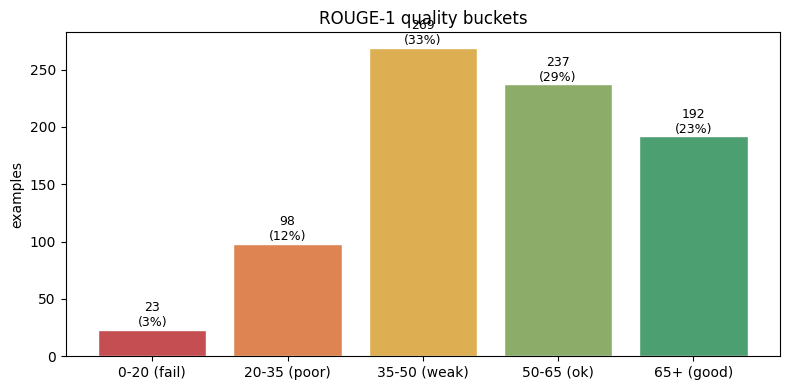

In [7]:
# Threshold buckets for ROUGE-1 — shifted higher than the Chinese notebook since English SAMSum scores are stronger.
bins = [-0.01, 20, 35, 50, 65, 100.01]
labels = ['0-20 (fail)', '20-35 (poor)', '35-50 (weak)', '50-65 (ok)', '65+ (good)']
df['r1_bucket'] = pd.cut(df['rouge1'], bins=bins, labels=labels)
bucket_counts = df['r1_bucket'].value_counts().reindex(labels)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#C44E52', '#DD8452', '#DDAE52', '#8CAD6A', '#4C9F70']
bars = ax.bar(bucket_counts.index, bucket_counts.values, color=colors, edgecolor='white')
for bar, count in zip(bars, bucket_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{count}\n({count/len(df):.0%})', ha='center', fontsize=9)
ax.set_title('ROUGE-1 quality buckets')
ax.set_ylabel('examples')
plt.tight_layout()
plt.show()

## 4. Metric agreement

Two questions here:
1. **ROUGE vs BERTScore** — do lexical and semantic metrics rank examples similarly? Weak correlation = the two signals disagree, meaning ROUGE alone under-rewards paraphrases.
2. **Raw vs rescaled BERTScore** — rank correlation should be ~1.0 because rescaling is monotonic. Pearson can differ slightly if the rescaling is not perfectly linear for this dataset.

In [8]:
pearson = df[METRICS].corr(method='pearson').round(3)
spearman = df[METRICS].corr(method='spearman').round(3)

print('Pearson (linear):')
print(pearson)
print('\nSpearman (rank):')
print(spearman)

Pearson (linear):
                rouge1  rouge2  rougeL  bs_f1_raw  bs_f1_rescaled
rouge1           1.000   0.860   0.901      0.844           0.844
rouge2           0.860   1.000   0.899      0.770           0.770
rougeL           0.901   0.899   1.000      0.856           0.856
bs_f1_raw        0.844   0.770   0.856      1.000           1.000
bs_f1_rescaled   0.844   0.770   0.856      1.000           1.000

Spearman (rank):
                rouge1  rouge2  rougeL  bs_f1_raw  bs_f1_rescaled
rouge1           1.000   0.842   0.882      0.814           0.814
rouge2           0.842   1.000   0.866      0.726           0.726
rougeL           0.882   0.866   1.000      0.828           0.828
bs_f1_raw        0.814   0.726   0.828      1.000           1.000
bs_f1_rescaled   0.814   0.726   0.828      1.000           1.000


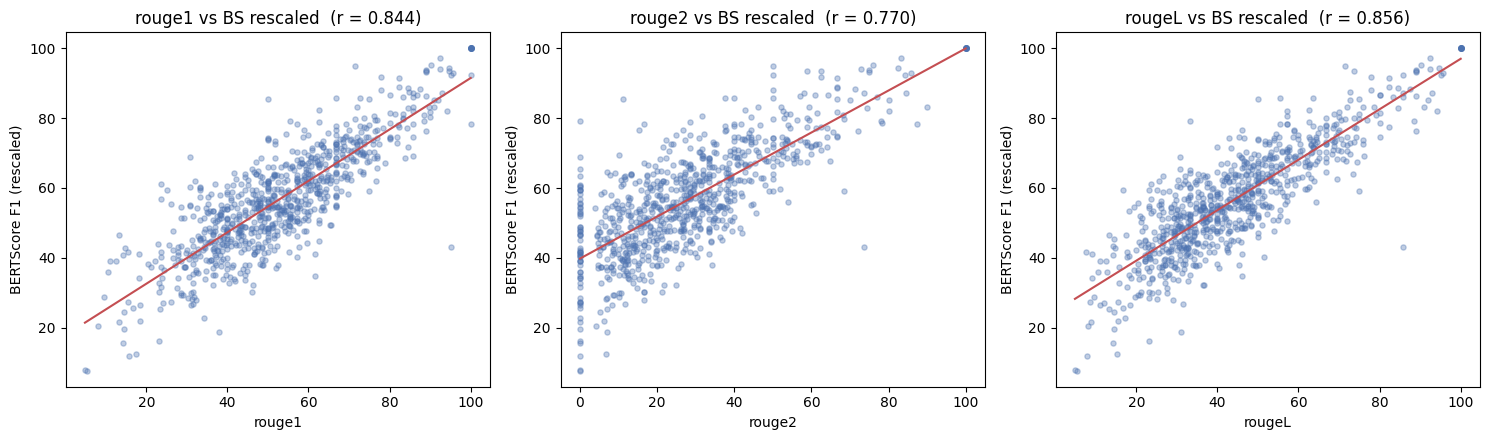

In [9]:
# Scatter: ROUGE variants vs BERTScore rescaled. Using rescaled here because raw is compressed in the 85-95 range
# and the scatter is hard to read visually.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric in zip(axes, ROUGE_METRICS):
    ax.scatter(df[metric], df['bs_f1_rescaled'], alpha=0.35, s=14, color='#4C72B0')
    r = df[[metric, 'bs_f1_rescaled']].corr().iloc[0, 1]
    ax.set_xlabel(metric)
    ax.set_ylabel('BERTScore F1 (rescaled)')
    ax.set_title(f'{metric} vs BS rescaled  (r = {r:.3f})')
    z = np.polyfit(df[metric], df['bs_f1_rescaled'], 1)
    xs = np.linspace(df[metric].min(), df[metric].max(), 50)
    ax.plot(xs, np.poly1d(z)(xs), color='#C44E52', linewidth=1.5)
plt.tight_layout()
plt.show()

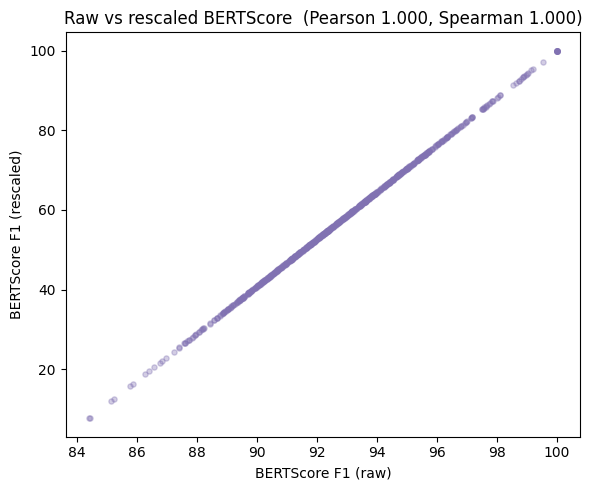

In [10]:
# Raw vs rescaled BERTScore — should be a tight monotonic relationship.
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df['bs_f1_raw'], df['bs_f1_rescaled'], alpha=0.35, s=14, color='#8172B2')
ax.set_xlabel('BERTScore F1 (raw)')
ax.set_ylabel('BERTScore F1 (rescaled)')
r_p = df[['bs_f1_raw','bs_f1_rescaled']].corr(method='pearson').iloc[0,1]
r_s = df[['bs_f1_raw','bs_f1_rescaled']].corr(method='spearman').iloc[0,1]
ax.set_title(f'Raw vs rescaled BERTScore  (Pearson {r_p:.3f}, Spearman {r_s:.3f})')
plt.tight_layout()
plt.show()

## 5. Length effects

For English, length in **words** is more meaningful than characters. Short references in SAMSum are often one-sentence summaries; the BART summarizer is known to over-generate on casual dialogue, so length ratio (prediction/reference) is a useful diagnostic.

In [11]:
df['ref_len'] = df['reference'].str.split().str.len()       # word count
df['pred_len'] = df['prediction'].str.split().str.len()
df['len_ratio'] = df['pred_len'] / df['ref_len'].clip(lower=1)

print('Reference length (words):')
print(df['ref_len'].describe().round(1))
print('\nPrediction length (words):')
print(df['pred_len'].describe().round(1))
print(f"\nMean length ratio (pred/ref): {df['len_ratio'].mean():.2f}")
print(f"Median length ratio: {df['len_ratio'].median():.2f}")

Reference length (words):
count    819.0
mean      20.0
std       10.7
min        3.0
25%       12.0
50%       18.0
75%       26.0
max       58.0
Name: ref_len, dtype: float64

Prediction length (words):
count    819.0
mean      19.1
std       11.0
min        2.0
25%       11.0
50%       17.0
75%       25.0
max       79.0
Name: pred_len, dtype: float64

Mean length ratio (pred/ref): 1.08
Median length ratio: 0.92


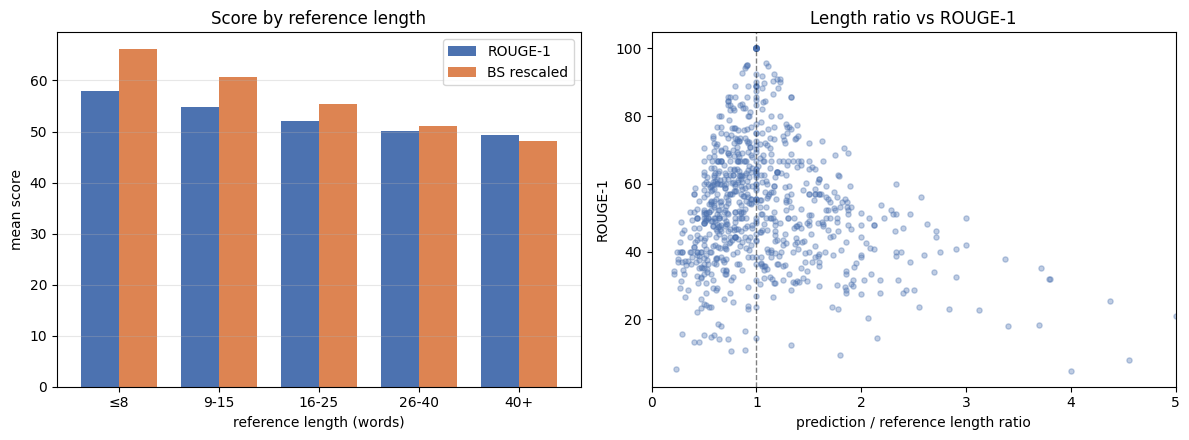

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Binned mean score by reference length (in words).
df['len_bin'] = pd.cut(df['ref_len'], bins=[0, 8, 15, 25, 40, 200],
                        labels=['≤8', '9-15', '16-25', '26-40', '40+'])
grouped = df.groupby('len_bin', observed=True)[['rouge1', 'bs_f1_rescaled']].mean()
x = np.arange(len(grouped))
width = 0.38
axes[0].bar(x - width/2, grouped['rouge1'], width, label='ROUGE-1', color='#4C72B0')
axes[0].bar(x + width/2, grouped['bs_f1_rescaled'], width, label='BS rescaled', color='#DD8452')
axes[0].set_xticks(x)
axes[0].set_xticklabels(grouped.index)
axes[0].set_xlabel('reference length (words)')
axes[0].set_ylabel('mean score')
axes[0].set_title('Score by reference length')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Length ratio vs ROUGE-1. Ratio > 1 = over-generation, < 1 = under-generation.
axes[1].scatter(df['len_ratio'], df['rouge1'], alpha=0.35, s=14, color='#4C72B0')
axes[1].axvline(1.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_xlabel('prediction / reference length ratio')
axes[1].set_ylabel('ROUGE-1')
axes[1].set_title('Length ratio vs ROUGE-1')
axes[1].set_xlim(0, 5)
plt.tight_layout()
plt.show()

## 6. Qualitative inspection

Ranked lists of interesting examples for manual review — best, worst, and cases where the two metric families disagree.

In [13]:
def show(subset, title):
    print(f'\n{"="*4} {title} {"="*4}')
    return subset[['reference', 'prediction', 'rouge1', 'rougeL', 'bs_f1_rescaled']].reset_index(drop=True)

show(df.nlargest(5, 'rougeL'), 'TOP 5 by ROUGE-L')


==== TOP 5 by ROUGE-L ====


,reference,prediction,rouge1,rougeL,bs_f1_rescaled
0,Edson is booking his ticket now.,Edson is booking his ticket now.,100.0,100.0,100.0
1,Sean overslept again.,Sean overslept again.,100.0,100.0,100.0
2,Emilia is still angry.,Emilia is still angry.,100.0,100.0,100.0
3,Joy is coming back on Thursday.,Joy is coming back on Thursday.,100.0,100.0,100.0
4,"Trinny, Susannah and Linda will meet at 6 at the main entrance.","Trinny, Susannah and Linda will meet at 6 at the main entrance.",100.0,100.0,100.0


In [14]:
show(df.nsmallest(5, 'rougeL'), 'BOTTOM 5 by ROUGE-L')


==== BOTTOM 5 by ROUGE-L ====


,reference,prediction,rouge1,rougeL,bs_f1_rescaled
0,Cyprien irritates Adelina by giving too many responses.,"Cyprien was born in Jarrow and lives in London now. He was educated in Loughborouogh, so in a sense he came from there. In another sense he comes from his m...",4.88,4.88,7.79
1,"Richie and Clay saw a very good football game, with one football player chopping the ball back to his foot, which was particularly exciting. Jose has trust ...",Pogba scored after his first 60 minutes.,5.41,5.41,7.65
2,Cole and Luis are sitting in the same room and yet they're texting each other.,Luis doesn't want Cole to talk to his roommate.,15.38,7.69,41.56
3,In the agreement it was decided that it's neither a sea nor a lake and it will have a special legal status. They will also completely divide the seabed up. ...,"Jeff, Vladimir, Donald and Tanya are discussing the Caspian Sea agreement.",15.69,7.84,11.96
4,Michelle is not in favor of contemporary feminism movement.,Melissa is not ok with men acting like pigs and grabbing you whenever they feel like it. She had a friend get yelled at by a girl for 5 minutes because he h...,8.00,8.00,20.43


In [15]:
# Z-score each metric, then rank by the absolute difference to find disagreement cases.
df['_r1_z'] = (df['rouge1'] - df['rouge1'].mean()) / df['rouge1'].std()
df['_bs_z'] = (df['bs_f1_rescaled'] - df['bs_f1_rescaled'].mean()) / df['bs_f1_rescaled'].std()
df['_gap'] = df['_bs_z'] - df['_r1_z']   # positive => BERTScore rewards it more than ROUGE-1 does

print('BERTScore rewards, ROUGE-1 penalizes — likely paraphrase / abstractive rewording:')
show(df.nlargest(5, '_gap'), '')

BERTScore rewards, ROUGE-1 penalizes — likely paraphrase / abstractive rewording:

====  ====


,reference,prediction,rouge1,rougeL,bs_f1_rescaled
0,Both Claire and Linda are making curry for dinner.,Linda is cooking curry.,30.77,30.77,68.78
1,Ludmila's favourite dinosaur when she was little was the Triceratops.,Ludmila's favorite dinosaur growing up was a triceratops.,50.00,50.00,85.38
2,Irene will take Crystal's son shopping for clothes.,Irene is going shopping with her little boy.,23.53,23.53,61.00
3,Ken is trying to play a prank on Greg.,Ken wants his money back from Greg.,25.00,25.00,59.43
4,Mike suspects he might have had an allergic reaction to something.,Mike woke up with an allergy.,23.53,23.53,56.96


In [16]:
print('ROUGE-1 rewards, BERTScore penalizes — likely surface-level word overlap without shared meaning:')
show(df.nsmallest(5, '_gap'), '')

ROUGE-1 rewards, BERTScore penalizes — likely surface-level word overlap without shared meaning:

====  ====


,reference,prediction,rouge1,rougeL,bs_f1_rescaled
0,Kane recommends the new 30 Seconds to Mars album to Shannon.,Kane recommends Shannon the new 30 seconds to mars album.,95.24,85.71,42.95
1,"Marta sent a file accidentally,",Marta accidentally sent Agnieszka and Weronika a gif.,61.54,46.15,34.85
2,"Will had to stand long in a queue at the post. Chris believe it is part of life in a big city. Will believes it is because of old people, who do not use the...",Will is standing in a line longer than the post office itself in order to send a letter in the XXI century.,37.93,31.03,18.74
3,"The content for November email blast is on the Dropbox, no need to send it.",Rhonda will send Precious the content for the November email blast.,61.54,46.15,41.08
4,"Dwayne will watch the new season of ""Jersey Shore"" on Zack's advice. The first episodes of the new season are hilarious. Season 2 is upcoming.","Zack watched a couple of episodes of the new Jersey Shore season. It's the original cast with Snooki, J-Wow, Pauly D, Ron, The Situation, Deena and Vinny. T...",45.98,25.29,30.12


## 7. Summary table

In [17]:
summary = pd.DataFrame({
    'model': ['BART'],
    'dataset': ['XSAMSum (en intermediate)'],
    'n': [len(df)],
    'ROUGE-1': [df['rouge1'].mean().round(2)],
    'ROUGE-2': [df['rouge2'].mean().round(2)],
    'ROUGE-L': [df['rougeL'].mean().round(2)],
    'BS F1 raw': [df['bs_f1_raw'].mean().round(2)],
    'BS F1 rescaled': [df['bs_f1_rescaled'].mean().round(2)],
    'R-1 fails (==0)': [int((df['rouge1'] == 0).sum())],
})
summary

,model,dataset,n,ROUGE-1,ROUGE-2,ROUGE-L,BS F1 raw,BS F1 rescaled,R-1 fails (==0)
0,BART,XSAMSum (en intermediate),819,52.94,28.33,44.43,92.71,56.83,0


## 8. EN→ZH drop (optional, run if the Chinese CSV is present)

This cell computes the per-pair score drop from the English stage to the Chinese translation stage. This isolates how much of the final Chinese quality loss comes from translation (as opposed to summarization), assuming both files are aligned row-for-row.

**Caveat:** raw BERTScore is not comparable across `roberta-large` (English) and `chinese-bert-wwm-ext` (Chinese) because they're different encoders on different languages. Only ROUGE is meaningfully comparable here, and even then only approximately — the jieba-segmented Chinese tokens aren't the same units as English whitespace-split words.

In [19]:
import os
ZH_PATH = 'pair_scores_zh_XSAMSum_bart.csv'

if os.path.exists(ZH_PATH):
    zh = pd.read_csv(ZH_PATH, index_col=0)
    if len(zh) == len(df):
        drop = pd.DataFrame({
            'metric': ROUGE_METRICS,
            'EN mean': [df[m].mean().round(2) for m in ROUGE_METRICS],
            'ZH mean': [zh[m].mean().round(2) for m in ROUGE_METRICS],
            'drop (EN - ZH)': [(df[m].mean() - zh[m].mean()).round(2) for m in ROUGE_METRICS],
            'drop %': [((df[m].mean() - zh[m].mean()) / df[m].mean() * 100).round(1) for m in ROUGE_METRICS],
        })
        print('ROUGE score drop from English intermediate to Chinese final:')
        print(drop.to_string(index=False))
    else:
        print(f'Row count mismatch: EN has {len(df)}, ZH has {len(zh)} — skipping comparison.')
else:
    print(f'{ZH_PATH} not found in working directory — skipping EN→ZH comparison.')

ROUGE score drop from English intermediate to Chinese final:
metric  EN mean  ZH mean  drop (EN - ZH)  drop %
rouge1    52.94    36.21           16.73    31.6
rouge2    28.33    13.38           14.95    52.8
rougeL    44.43    30.71           13.71    30.9


## Notes / follow-ups

- **Both raw and rescaled BERTScore are included.** Report rescaled for reader interpretability; keep raw for direct comparison with any paper that didn't rescale.
- **Multilingual ROUGE toolkit, English config.** Scores here come from the same toolkit used for the Chinese stage (with English tokenizer + Porter stemming), so they are directly comparable to the final Chinese ROUGE numbers in the Section 8 drop analysis.
- **Expected profile vs Chinese.** English SAMSum is well-studied and BART baselines are strong, so R-1 ≈ 50+ is normal here. The drop to ~42 on the Chinese side in our companion notebook mostly reflects the translation step — dialogue-specific entities (names, colloquialisms, slang) don't always translate cleanly.